# 知識蒸餾改進版

**改進項目（皆為正規知識蒸餾方法）：**

1. **強化教師模型**：原版直接將 ImageNet 版 ResNet18（7×7 stride-2 conv + maxpool）用於 32×32 的 CIFAR-10，
   第一層就把特徵圖縮到 8×8，教師本身學不好，產生的軟標籤品質也差。
   改為 CIFAR 友善版（3×3 stride-1 conv、移除 maxpool），並用資料增強 + SGD momentum + cosine 學習率排程訓練。
   教師品質是蒸餾效果最重要的因素。
2. **調整蒸餾超參數**：溫度 T 由 3 → 4；hard-label 權重 alpha 由 0.5 → 0.1。
   教師夠強時，讓學生主要學習軟標籤中「類別間相似度」的暗知識（dark knowledge）效果最好。
3. **進階蒸餾方式：Attention Transfer**（Zagoruyko & Komodakis, ICLR 2017）：
   除了 logits 蒸餾外，再讓學生模仿教師中間層的空間注意力圖（spatial attention map）。
4. **公平比較**：未蒸餾的 baseline 學生訓練方式與原版完全相同（同架構、Adam lr=0.001、50 epochs）；
   蒸餾學生使用相同的架構、optimizer 與 epochs，僅替換損失函數。改善幅度純粹來自蒸餾本身。


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True
print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")

# 資料前處理（與原版相同，學生的訓練/測試資料完全不變）
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 教師專用的資料增強（只用來提升教師品質，不影響兩個學生之間的公平比較）
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_data_aug = datasets.CIFAR10(root='./data', train=True, transform=transform_aug, download=True)
test_data = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=512, shuffle=True)
teacher_loader = torch.utils.data.DataLoader(train_data_aug, batch_size=512, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=512, shuffle=False)

Using device: cuda


In [2]:
# 大模型 (Teacher)：CIFAR 友善版 ResNet18
# 把第一層 7x7 stride-2 conv 換成 3x3 stride-1，並移除 maxpool，
# 讓 32x32 輸入保留完整空間資訊，教師準確率大幅提升 → 軟標籤更有資訊量
teacher_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
teacher_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
teacher_model.maxpool = nn.Identity()
teacher_model.fc = nn.Linear(512, 10)  # CIFAR-10 類別數
teacher_model = teacher_model.cuda()

# 小模型 (Student)：與原版完全相同
class StudentCNN(nn.Module):
    def __init__(self):
        super(StudentCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

student_model = StudentCNN()
student_model = student_model.cuda()

student_model_distilled = StudentCNN()
student_model_distilled = student_model_distilled.cuda()

In [3]:
# 知識蒸餾損失函數 (Hinton et al., 2015)
# 超參數改進：T 由 3 → 4，alpha (hard-label 權重) 由 0.5 → 0.1
def distillation_loss(student_logits, teacher_logits, targets, T, alpha):
    soft_targets = nn.functional.softmax(teacher_logits / T, dim=1)
    soft_loss = nn.functional.kl_div(
        nn.functional.log_softmax(student_logits / T, dim=1),
        soft_targets, reduction='batchmean'
    ) * (T * T)
    hard_loss = nn.functional.cross_entropy(student_logits, targets)
    return alpha * hard_loss + (1 - alpha) * soft_loss


# 進階蒸餾：Attention Transfer (Zagoruyko & Komodakis, ICLR 2017)
# 將特徵圖沿 channel 取平方平均得到空間注意力圖，再做 L2 正規化後比較。
# 注意力圖與 channel 數無關，因此教師 (256ch) 與學生 (64ch) 的 8x8 特徵可直接對齊。
def attention_map(feat):
    am = feat.pow(2).mean(dim=1).flatten(1)  # (B, H*W)
    return nn.functional.normalize(am, dim=1)

def attention_loss(student_feat, teacher_feat):
    return (attention_map(student_feat) - attention_map(teacher_feat)).pow(2).mean()

In [4]:
# 測試函數（與原版相同）
def test_model(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [5]:
# 一般訓練函數（教師與 baseline 學生用；baseline 學生的用法與原版完全相同）
def train_model(model, criterion, optimizer, loader=None, epochs=5, scheduler=None):
    loader = loader if loader is not None else train_loader
    train_loss = []
    epoch_accuracies = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, labels in loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if scheduler is not None:
            scheduler.step()

        avg_loss = epoch_loss / len(loader)
        train_loss.append(avg_loss)
        accuracy = test_model(model)
        epoch_accuracies.append(accuracy)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return train_loss, epoch_accuracies


# 蒸餾訓練函數：Hinton KD + Attention Transfer
def train_distilled(student, teacher, optimizer, epochs, T, alpha, beta):
    # 用 forward hook 抓中間層特徵：教師 layer3 與學生 features 的輸出空間大小都是 8x8
    feats = {}
    def save_to(name):
        def hook(module, inp, out):
            feats[name] = out
        return hook
    h_t = teacher.layer3.register_forward_hook(save_to('teacher'))
    h_s = student.features.register_forward_hook(save_to('student'))

    teacher.eval()  # 教師固定不動，關閉 BN / Dropout 的訓練行為
    train_loss, epoch_accuracies = [], []
    for epoch in range(epochs):
        student.train()
        epoch_loss = 0
        for images, labels in train_loader:
            images, labels = images.cuda(), labels.cuda()
            with torch.no_grad():
                teacher_logits = teacher(images)
            student_logits = student(images)
            loss = distillation_loss(student_logits, teacher_logits, labels, T=T, alpha=alpha)
            loss = loss + beta * attention_loss(feats['student'], feats['teacher'])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_loss.append(avg_loss)
        accuracy = test_model(student)
        epoch_accuracies.append(accuracy)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

    h_t.remove()
    h_s.remove()
    return train_loss, epoch_accuracies

In [6]:
epoch = 50

# 訓練教師模型：SGD + momentum + cosine 學習率排程 + 資料增強
criterion = nn.CrossEntropyLoss()
teacher_optimizer = optim.SGD(teacher_model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
teacher_scheduler = optim.lr_scheduler.CosineAnnealingLR(teacher_optimizer, T_max=epoch)
print("Training teacher model...")
teacher_loss, teacher_acc = train_model(teacher_model, criterion, teacher_optimizer,
                                        loader=teacher_loader, epochs=epoch,
                                        scheduler=teacher_scheduler)

# baseline 學生：與原版完全相同的訓練方式（Adam lr=0.001、無蒸餾、無增強）
student_optimizer = optim.Adam(student_model.parameters(), lr=0.001)
print("Training student model without distillation...")
non_distilled_loss, non_distilled_acc = train_model(student_model, criterion,
                                                    student_optimizer, epochs=epoch)

# 蒸餾學生：相同架構、相同 optimizer 設定、相同 epochs，只把損失換成 KD + Attention Transfer
distilled_optimizer = optim.Adam(student_model_distilled.parameters(), lr=0.001)
print("Training student model with distillation...")
distilled_loss, distilled_acc = train_distilled(
    student_model_distilled, teacher_model, distilled_optimizer,
    epochs=epoch, T=4, alpha=0.1, beta=500
)

Training teacher model...
Epoch [1/50], Loss: 0.8551, Accuracy: 0.8203
Epoch [2/50], Loss: 0.3577, Accuracy: 0.8536
Epoch [3/50], Loss: 0.2551, Accuracy: 0.8906
Epoch [4/50], Loss: 0.2011, Accuracy: 0.8924
Epoch [5/50], Loss: 0.1703, Accuracy: 0.8947
Epoch [6/50], Loss: 0.1459, Accuracy: 0.9037
Epoch [7/50], Loss: 0.1275, Accuracy: 0.9155
Epoch [8/50], Loss: 0.1094, Accuracy: 0.9155
Epoch [9/50], Loss: 0.1023, Accuracy: 0.9219
Epoch [10/50], Loss: 0.0902, Accuracy: 0.9223
Epoch [11/50], Loss: 0.0801, Accuracy: 0.9262
Epoch [12/50], Loss: 0.0760, Accuracy: 0.9167
Epoch [13/50], Loss: 0.0725, Accuracy: 0.9311
Epoch [14/50], Loss: 0.0569, Accuracy: 0.9281
Epoch [15/50], Loss: 0.0517, Accuracy: 0.9313
Epoch [16/50], Loss: 0.0464, Accuracy: 0.9298
Epoch [17/50], Loss: 0.0380, Accuracy: 0.9339
Epoch [18/50], Loss: 0.0397, Accuracy: 0.9268
Epoch [19/50], Loss: 0.0406, Accuracy: 0.9309
Epoch [20/50], Loss: 0.0298, Accuracy: 0.9321
Epoch [21/50], Loss: 0.0299, Accuracy: 0.9347
Epoch [22/50], Lo

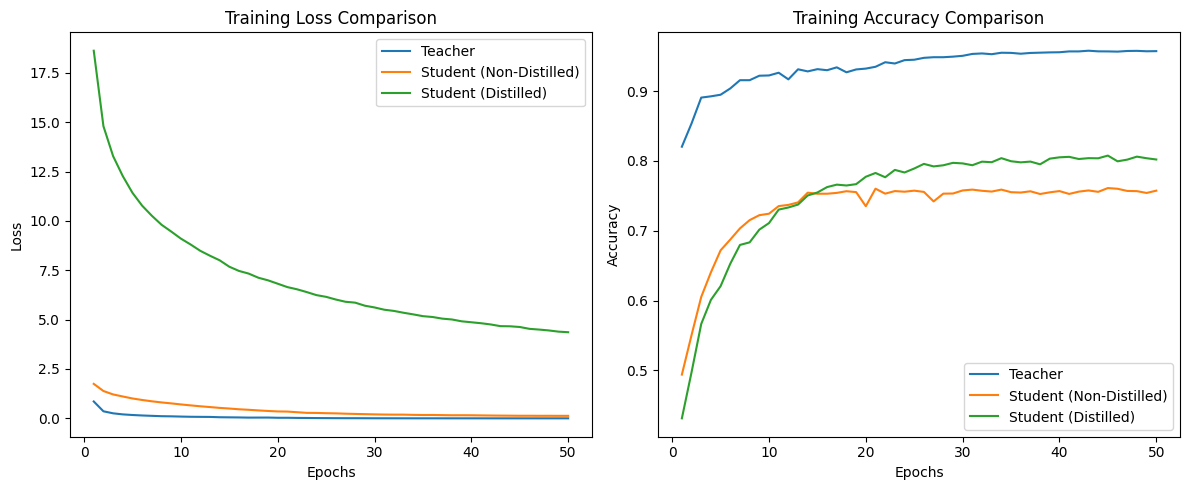

teacher parameters: 11,173,962
student parameters: 1,116,970
蒸餾效果提升: 0.0446
蒸餾得分: 94.60


In [7]:
# 繪圖比較
epochs = range(1, epoch+1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, teacher_loss, label='Teacher')
plt.plot(epochs, non_distilled_loss, label='Student (Non-Distilled)')
plt.plot(epochs, distilled_loss, label='Student (Distilled)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, teacher_acc, label='Teacher')
plt.plot(epochs, non_distilled_acc, label='Student (Non-Distilled)')
plt.plot(epochs, distilled_acc, label='Student (Distilled)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()

plt.tight_layout()
plt.show()

total_params_deep = "{:,}".format(sum(p.numel() for p in teacher_model.parameters()))
print(f"teacher parameters: {total_params_deep}")
total_params_light = "{:,}".format(sum(p.numel() for p in student_model.parameters()))
print(f"student parameters: {total_params_light}")

# 蒸餾分數計算
improvement = distilled_acc[-1] - non_distilled_acc[-1]
score = min(max(0, 50 + improvement * 1000), 100)
print(f"蒸餾效果提升: {improvement:.4f}")
print(f"蒸餾得分: {score:.2f}")